# Logistic regression

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Understand logistic regression;
- Understand the differences between logistic regression and linear discriminant analysis;
- Understand the probablistic output of logistic regression.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


In [2]:
from pathlib import Path
import pickle
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

## Exercise 1: Optimization function of logistic regression

The following cost function for logistic regression needs to get minimized to determine the optimal choice of the parameters $\mathbf{w}$:

\begin{equation}
J_{1}(w) = \sum_{i=1}^{N_{samples}} \ln(\exp(-\mathbf{y_{i}}(\mathbf{w}^{\rm T}\mathbf{x_{i}}))+1)
\end{equation}

Assuming linear separability of a given data set, what can happen to the weights $\mathbf w$ when minimizing the cost function $J_{1}(\mathbf{w})$? Why is this a problem? 

**Hint:** Assume there exists a weight vector $\mathbf{\tilde w}$ such that $\mathbf{y_{i}}(\mathbf{\tilde w}^{\rm T}\mathbf{x_{i}}) > 0$ for all sample points $i$. The class labels are defined as $y_{i}=\{-1,1\}$.

**Hint:** Plot this function to get an intuition for what this function looks like.

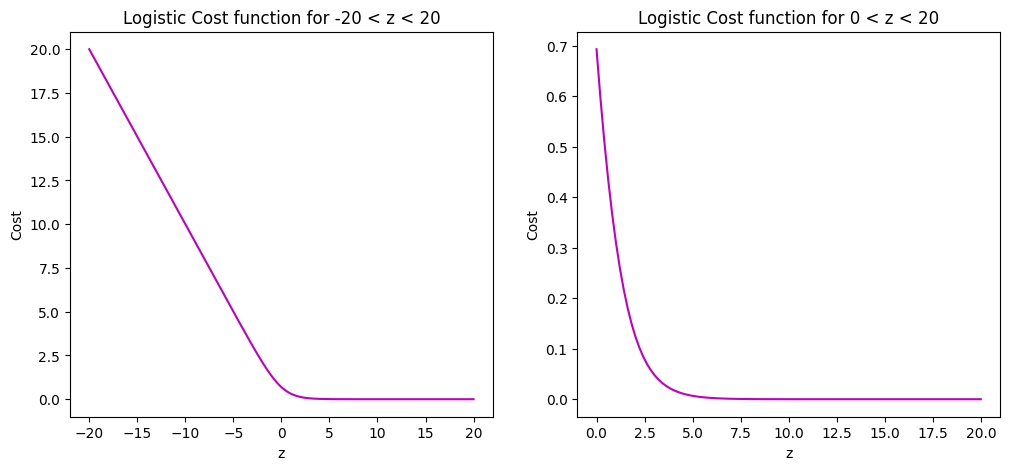

In [3]:
z_vals_big = np.linspace(-20, 20, 200)
y_vals_big = np.log(np.exp(-z_vals_big) + 1)
z_vals_small = np.linspace(0, 20, 100)
y_vals_small = np.log(np.exp(-z_vals_small) + 1)

figure, axes = plt.subplots(1, 2, figsize = (12, 5))
axes[0].plot(z_vals_big, y_vals_big, color = "m")
axes[0].set_xlabel("z")
axes[0].set_ylabel("Cost")
axes[0].set_title("Logistic Cost function for -20 < z < 20")
axes[1].plot(z_vals_small, y_vals_small, color = "m")
axes[1].set_xlabel("z")
axes[1].set_ylabel("Cost")
axes[1].set_title("Logistic Cost function for 0 < z < 20")

plt.show()

    Теперь проанализируем член z = yᵢ(wᵀxᵢ):
    wᵀxᵢ — это прогноз нашей модели (пока не пропущенный через сигмоиду).
    yᵢ — это истинная метка (+1 или -1).
    z = yᵢ(wᵀxᵢ) называется "отступом" (margin
* z > 0, то прогноз правильный (произведение прогноза и метки положительно), и модель уверена в своем прогнозе. Чем больше z, тем больше уверенность.  
* z < 0, то прогноз неправильный.

LEFT        Когда z маленький или отрицательный (модель ошибается), стоимость большая.    
          Когда z растет (модель угадывает правильно), стоимость падает.    
RIGHT        Видно, что даже при очень большом z стоимость никогда не становится нулем, она лишь все ближе и ближе к нему приближается. График почти горизонтален, но не касается нуля.    


Если данные идеально разделимы (прямая линия может без ошибок отделить один класс от другого), то алгоритм оптимизации будет пытаться сделать стоимость абсолютным нулем.  
Но, как видно на правом графике, стоимость никогда не станет нулем. Это заставляет алгоритм бесконечно увеличивать веса w, чтобы хоть чуть-чуть, но уменьшить стоимость.  
Итог: Веса w будут расти до бесконечности, что приводит к переобучению и численным проблемам. Модель станет слишком уверенной и хрупкой.

Решение: Добавить регуляризацию — специальный штраф в функцию стоимости за слишком большие веса, который не даст им бесконечно расти.

## Exercise 2: Adding regularization

A more stable estimate for $\mathbf{w}$ can be achieved when using the concept of **regularization**. Adding an additional term $J_{2}(\mathbf{w}) = \frac{1}{2}\mathbf{w}^{\rm T}\mathbf{w}$ to the cost function modifies the overall cost function $J(\mathbf{w},C)$ to: 

\begin{equation}
J(w,C) = J_{1}(\mathbf{w},C) + J_{2}(\mathbf{w}) = C\cdot \sum_{i=1}^{N_{samples}} \ln(\exp(-\mathbf{y}(\mathbf{w}^{\rm T}\mathbf{X}))+1) + \frac{1}{2}\mathbf{w}^{\rm T}\mathbf{w}
\end{equation}

Note, that the so-called regularization parameter $C$ determines the relation of the second cost function $J_{2}(w)$ with respect to the first cost function $J_{1}(w)$.

Which role has the additional cost function $J_{2}(w)$?

J₂(w) = (1/2) * wᵀw — это регуляризационный член, и его основная роль — не давать весам модели w становиться слишком большими.  

1) Без J₂(w): Если данные идеально разделимы, модель, пытаясь минимизировать стоимость J₁(w), будет бесконечно увеличивать веса w, что приводит к переобучению.

2) С J₂(w): Теперь мы минимизируем общую функцию J(w, C) = C * J₁(w) + J₂(w).
    * J₁(w) ("ошибка"): "Говорит" модели: "Стань увереннее в своих прогнозах, увеличивай веса w!"
    * J₂(w) ("штраф"): "Говорит" модели: "Не будь слишком сложной, не увеличивай веса w слишком сильно!"

Параметр C определяет, кого модель будет "слушать" больше:
* Если C очень большой, модель в основном слушает J₁(w) и старается любой ценой минимизировать ошибку на обучающих данных (рискуя переобучиться).
* Если C очень маленький, модель в основном слушает J₂(w) и старается сделать веса как можно меньше, даже в ущерб точности на обучающих данных (рискуя недообучиться).

## Exercise 3: Evaluate and visualize the output of a logistic regression model
Below we provide a dataset for this exercise. 
1. Visualize the given training data set using the class labels. 
2. Lookup the scikit-learn toolbox implementation of a Logistic Regression model. Then train a model on the given training data. Please make sure that you use an "L2-penalty" for regularization and set your regularization parameter to C = 1.
3. Use your trained Logistic Regression model to predict the class labels of the test data and report on the classification performance.
4. Inspect the given function `plot_probabilityMap` and use it to visualize the probability map of class "1" of your trained Logistic Regression model using the test data set as an input.

In [4]:
ds_trainData = 'data/spread_train.data'
ds_trainLabels ='data/spread_train.labels'
ds_testData = 'data/spread_test.data'
ds_testLabels ='data/spread_test.labels'

# load training data
X_train = np.loadtxt(ds_trainData)
y_train = np.loadtxt(ds_trainLabels)

# load test data
X_test = np.loadtxt(ds_testData)
y_test = np.loadtxt(ds_testLabels)

In [5]:
def plot_probabilityMap(model, X, y, yh, plot_means, class_index):
    '''visualizes the output of the applied models with a probability map
    INPUT: 
        'model'-> scikit-learn like instance of classifier models with built-in method 'predict_proba' available
        'X' -> data matrix of size NxD
        'y' -> true class labels
        'yh' -> predicted class labels
        'plot_means' -> only for LDA: adding class means to the plot
        'class_index' -> probability map for class, either '0' or '1'
    
    OUTPUT:
        fig: figure handle of the plot
    '''
    fig = plt.figure(figsize=(8, 4))
    
    tp = (y == yh)  # True Positive
    tp0, tp1 = tp[y == 0], tp[y == 1]
    X0, X1 = X[y == 0], X[y == 1]
    X0_tp, X0_fp = X0[tp0, :], X0[~tp0, :]
    X1_tp, X1_fp = X1[tp1, :], X1[~tp1, :]

    # class 0: true positives vs. false positives
    plt.plot(X0_tp[:, 0], X0_tp[:, 1], 'o', color='red', label="class 0 tp")
    plt.plot(X0_fp[:, 0], X0_fp[:, 1], 'o', color='salmon', label="class 0 fp")  # dark red

    # class 1:
    plt.plot(X1_tp[:, 0], X1_tp[:, 1], 'o', color='blue', label="class 1 tp")
    plt.plot(X1_fp[:, 0], X1_fp[:, 1], 'o', color='lightskyblue', label="class 1 fp")  # dark blue

    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.legend()
    
    # class 0 and 1 : areas
    nx, ny = 200, 100
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                         np.linspace(y_min, y_max, ny))
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z = Z[:, class_index].reshape(xx.shape)
    plt.pcolormesh(xx, yy, Z, cmap='YlOrBr', shading='auto')
    cbar = plt.colorbar()  # colorbar assigning the probabilities
    cbar.set_label('P(class={})'.format(class_index))
        
    # plot the contour of the 50 probability
    plt.contour(xx, yy, Z, [0.5], linewidths=2., colors='k')

    # plot class means (only makes sense for LDA)
    if plot_means: 
        plt.plot(model.means_[0][0], model.means_[0][1], 'o', color='black', markersize=10)
        plt.plot(model.means_[1][0], model.means_[1][1], 'o', color='black', markersize=10)

    return fig

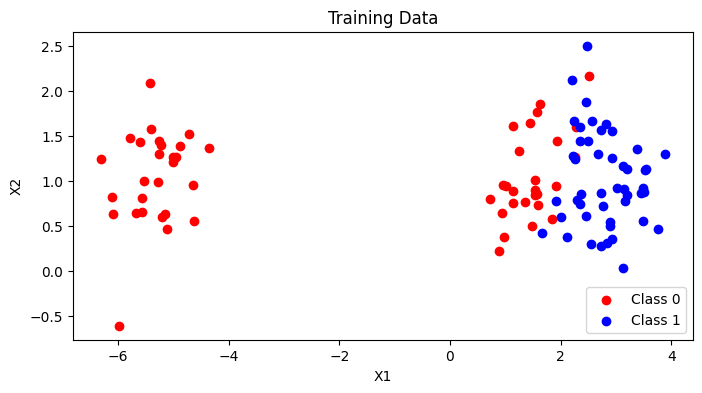

In [6]:
# Visualize the given training data set using the class labels.
plt.figure(figsize=(8, 4))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='red', label='Class 0')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='blue', label='Class 1')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Training Data')
plt.legend()
plt.show()

Accuracy: 0.89


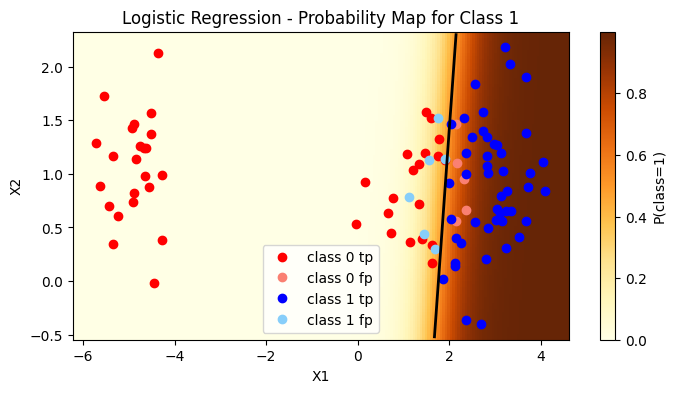

In [7]:
# Train a model on the given training data. Use an "L2-penalty" for regularization and set your regularization parameter to C = 1.
model = LogisticRegression(penalty='l2',  C=1.0)
model.fit(X_train, y_train)

# Use trained Logistic Regression model to predict the class labels of the test data and report on the classification performance.
y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy) #accuracy

# Use plot_probabilityMap to visualize the probability map of class "1" of your trained Logistic Regression model using the test data set as an input.
plot_probability =  plot_probabilityMap(model, X_test, y_test, y_pred, plot_means=False, class_index=1)
plt.title('Logistic Regression - Probability Map for Class 1')
plt.show()

## (Optional) Exercise 4: Comparison with performance of the LDA 

For comparison, you now need to train and evaluate an LDA model on the same data set and evaluate its performance.

1. Lookup the scikit-learn toolbox implementation for an LDA model. Then train a model on the given training data. Please specify your solver to "eigen".
2. Use your trained LDA model to predict the class labels of the test data and report on the classification performance.
3. Apply the given function `plot_probabilityMap` to visualize the probability map of class "1" of your trained LDA model taking the test data set as an input. Use the input parameter of the function to visualize the class means.
4. Compare the performance of the logistic regression model with the LDA model for the given dataset. Do you observe a severe difference in the performance of both models? Can you explain the reason? **Hint:** You can compare the two decision boundaries and the assumptions made by the methods.
5. How can you estimate a probability from an LDA classifier? Remember that this is not a probabilistic method by default.

Accuracy: 0.78


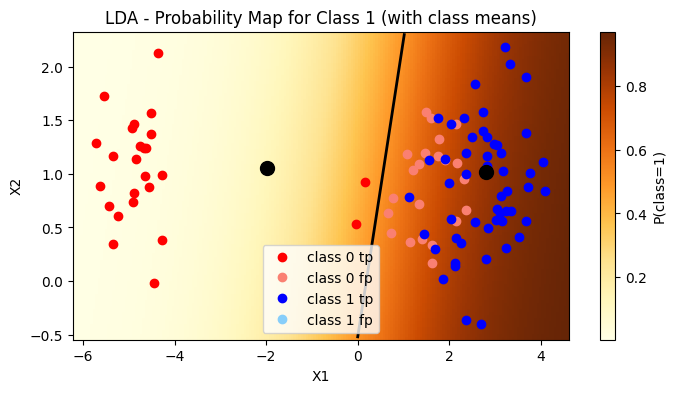

In [8]:
# Then train a model on the given training data. Please specify your solver to "eigen".
model_lda = LinearDiscriminantAnalysis(solver='eigen')
model_lda.fit(X_train, y_train)

# Use trained Logistic Regression model to predict the class labels of the test data and report on the classification performance.
y_pred_lda = model_lda.predict(X_test)
accuracy_lda =  model_lda.score(X_test, y_test)
print("Accuracy:", accuracy_lda) #accuracy

# Use plot_probabilityMap to visualize the probability map of class "1" of your trained Logistic Regression model using the test data set as an input.
plot_probability =  plot_probabilityMap(model_lda, X_test, y_test, y_pred_lda, plot_means=True, class_index=1)
plt.title('LDA - Probability Map for Class 1 (with class means)')
plt.show()

In [9]:
print("\n=== MODEL COMPARISON ===")
print(f"Logistic Regression Accuracy: {accuracy:.3f}")
print(f"LDA Accuracy: {accuracy_lda:.3f}")

if (accuracy - accuracy_lda) < 0.05:
    print("➡️ Производительность моделей примерно ОДИНАКОВАЯ")
else:
    print("➡️ Есть заметная разница в производительности")


=== MODEL COMPARISON ===
Logistic Regression Accuracy: 0.890
LDA Accuracy: 0.780
➡️ Есть заметная разница в производительности


#Подсказка:   Сравните границы решений и предположения, на которых основаны методы.
1) Логистическая регрессия:
    * Находит оптимальную разделяющую границу напрямую   --- ей не важно распределение, только где провести разделительную линию
    * Не делает предположений о распределении данных
    * Более гибкая для сложных границ

2) LDA:
    * Предполагает, что классы имеют нормальное распределение   ---если точки перемешаны, это нарушает предположение о "красивых" кластерах
    * Предполагает одинаковые ковариационные матрицы для всех классов   ---перемешанные точки создают разную форму распределений для классов
    * Использует информацию о средних и ковариации

Если производительность отличается:
* Данные могут не удовлетворять предположениям LDA (не нормальное распределение, разные ковариации)
* Логистическая регрессия может быть более robust к нарушениям предположений

#Вопрос:   Как можно оценить вероятность из классификатора LDA, если метод сам по себе не является вероятностным?


In [10]:
# LDA по умолчанию не является вероятностным методом,
# но в sklearn можно получить вероятности через Bayes rule:

# Получение вероятностей из LDA
probabilities_lda = model_lda.predict_proba(X_test)  #Предсказывает вероятности классов.
print("LDA probabilities for first 5 samples:")
print(probabilities_lda[:5])

# Формула преобразования LDA в вероятности:
# P(class|X) = exp(LDA_score) / sum(exp(LDA_scores))
# где LDA_score = линейная дискриминантная функция   

# сначала для каждого классса(баллы за каждую работу)     LDA_балл(score) = (коэффициенты × данные) + intercept 
#  баллы в вероятности через "мягкое преобразование       Вероятность_класса = exp(балл_класса) / (exp(балл_класса1) + exp(балл_класса2))
print(f"\nLDA coefficients: {model_lda.coef_}")   # важность признаков" (насколько X1 и X2 влияют на классификацию)   "вес" каждой задачи
print(f"LDA intercept: {model_lda.intercept_}")   # базовый уровень" (смещение границы решения)

LDA probabilities for first 5 samples:
[[0.23153757 0.76846243]
 [0.09500931 0.90499069]
 [0.11895273 0.88104727]
 [0.15451694 0.84548306]
 [0.2011673  0.7988327 ]]

LDA coefficients: [[ 0.75621517 -0.27227472]]
LDA intercept: [-0.14210831]


LDA использует Байесовское правило для преобразования линейных дискриминантных функций в вероятности:
* Сначала вычисляет LDA-скоры для каждого класса
* Затем применяет softmax функцию для получения вероятностей
* P(class=k|X) = exp(LDA_score_k) / ∑exp(LDA_score_j)
Вывод: Обе модели должны показать схожую производительность на линейно разделимых данных, но могут отличаться если нарушены предположения LDA о нормальности распределений

## Exercise 5: From classification results to BCI
In a real world BCI application, classification of a single event might you be an auxiliary step towards establishing a BCI control. Imagine a P300 speller in which you would perform a classification of each flashed image to `target` or `non-target`. In order to be able to spell with such a stimulus + decoding approach, you would still interpret a pooled set of classification results.

In this exercise, you will perform this last interpretation step to work from single trial classification results towards an usefull interpretation for a user interacting with such a BCI system. You are given a model trained on a real persons EEG data as well as a simulation generator which will provide simulated EEG data for `target` and `non-target` epochs parametriced to the same person.

**Question**: 
1. What would be the sentence that can be decoded with the given model?
2. How could you improve the decoding accuracy in this simulation? Please describe or implement.

In [11]:
# Given speller setup and pre-trained model

# Simulated speller data
#characters_matrix[i,j] — это один символ, строки и столбцы — те самые, которые будут «мигать».
characters_matrix = np.array(list('ABCDEFGHIJKLMNOPQRSTUVWXYZ1234567|~_')).reshape(6,6)  #матрица символов (6×6).
print('The BCI characters matrix:\n', characters_matrix) #
target = 'BB|~BB_IS_THE_QUESTION' #строка символов, которую «внимательно смотрит» пользователь (т.е. что мы хотим расшифровать)

# Load some parameters resulting from a real subjects decoding
# строит путь к файлу data/simulation_parameters.pickle в текущей рабочей папке.
p = Path.cwd().joinpath('data', 'simulation_parameters.pickle') #simulation_parameters.pickle содержит статистические параметры (mean for target, mean for nontarget, covariance) — модель генерации фазовых признаков.
d = pickle.load(open(p,'rb')) #загружает из файла сериализованные данные (словарь d) — это параметры, полученные ранее от реального субъекта / предварительного анализа.
means_target = d['mean_Target']  # Средние значения EEG для целевых стимулов
means_non_target = d['mean_Nontarget'] # вектор средних признаков для нецелевых эпох (нет P300).
cov = d['cov']                     # Ковариационная матрица признаков (шум/взаимосвязь между признаками).
#то не реальные текущие EEG-данные — это статистика, полученная заранее (offline) из помеченных данных (калибровки или данных других испытуемых)


# --- Функция генерации одной эпохи ---
# генерирует одну симулированную эпоху (feature-вектор) в ответ на одно мигание (подсветку
# функция имитирует ответ мозга на одну подсветку: целевой → «P300-подобный» сигнал, нецелевой → «фон».
def sample_one_simulated_trial(char, highlighted,      #символ= внимания пользователя (target for current trial); абор символов= в этот момент подсветили (row or col); это массив/список длины 6.
                               means_target=means_target,
                               means_non_target=means_non_target,
                               cov=cov):  
    #char и highlighted в симуляции известны, потому что мы управляем экспериментом (мы задаём цель target и порядок подсветок). 
    #В реальномэксперименте такой «ground truth» доступен только для калибровки: экспериментатор её задаёт заранее
    if char in highlighted: #входит ли целевой символ char в текущую подсвеченную строку/столбец highlighted
        # Генерирует EEG-сигнал как при взгляде на нужный символ
        #нужно сгенерировать эпоху, похожую на ту, где есть P300.
        X = np.random.multivariate_normal(means_target, cov)  #возвращается выборка из нормального распределения с means_target
    else:
        X = np.random.multivariate_normal(means_non_target, cov) #иначе с means_non_target
    return X #Это имитирует отличающийся средний отклик для target vs non-target.


# --- Генератор онлайн-эпох ---
#Generator имитирует поток эпох, который в реальной системе поступал бы с устройства EEG. потому знаем target that user focus, highlited row or col
# real online: not know char, eeg epoch saves after each flash --> after by them decode target by classificatoe (was learned on callibr data)
# query for EEG data
def get_target_online_generator(target=target, n_reps=5): #генерирует в порядке, как в онлайн-системе:
    """ A generator function simulating a real online BCI data acquisition получение """
    i = 0
    while True and i < len(target): #
        # print('>>> NEXT CHARACTER')
        char = target[i] # Текущий символ, на который смотрит пользователь
        # print(f'"I am focussing on character [{char}]" - {i=}')
        
        # Assume a very simple way of speller were we iterate over the rows and
        # over the columns 5 times
        for j in range(n_reps): #для каждого символа n_reps раз по всем строкам
            for row in characters_matrix:
                yield sample_one_simulated_trial(char, row) #Это соответствует одной подсветке (миганию) строки.
            for col in characters_matrix.T: #затем по всем столбцам,
                yield sample_one_simulated_trial(char, col) #выдавая по одной эпохе за итерацию
        i += 1
        # Каждая yield — это симуляция того, что система в реальном времени получает от EEG после одной подсветки (одной эпохи).
        # Последовательность yield-ов имитирует реальные последовательные мигания, которые спеллер делает онлайн.

# --- Загрузка предобученного классификатора ---
# load the classifier from wherever you stored the axiliary data
lda = joblib.load('./data/lda_subj2_slow.joblib') #предобученный классификатор, который принимает вектор признаков эпохи и возвращает вероятность/скор того, что эпоха — target.

The BCI characters matrix:
 [['A' 'B' 'C' 'D' 'E' 'F']
 ['G' 'H' 'I' 'J' 'K' 'L']
 ['M' 'N' 'O' 'P' 'Q' 'R']
 ['S' 'T' 'U' 'V' 'W' 'X']
 ['Y' 'Z' '1' '2' '3' '4']
 ['5' '6' '7' '|' '~' '_']]


C:\ProgramData\anaconda3\envs\bci-BKI323\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LinearDiscriminantAnalysis from version 1.1.3 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


1) lda обычно имеет методы вроде .predict, .decision_function или .predict_proba, которые можно применять к каждой эпохе (вектору X) и получать скор/вероятность, указывающую на то, целевая это эпоха или нет.
2) В рабочем пайплайне: на каждую сгенерированную эпоху выполняют score = lda.decision_function(X.reshape(1,-1)) (или predict_proba), затем суммируют/усредняют эти скоры отдельно для каждой строки и каждого столбца, и по argmax настраивают выбранную строку и столбец → получаем символ.
3) Что возвращает sample_one_simulated_trial?
    — Один вектор признаков (эпоха). Этот вектор моделирует EEG-отклик после одного мигания (строки или столбца). Если подсветка включает целевой символ → вектор с P300-подписью (смещённый относительно means_target), иначе — фон.
4)

1) Вопрос 1: Какое предложение можно декодировать?     Нужно написать алгоритм, который:
    * Берет предобученную LDA-модель
    * Обрабатывает симулированные EEG-данные
    * Определяет, какие символы "думал" пользователь
    * Восстанавливает фразу target = 'BB|~BB_IS_THE_QUESTION'  
  
2) Вопрос 2: Как улучшить точность декодирования?       Возможные подходы:
    * Увеличить количество повторений (n_reps)
    * Улучшить модель классификации
    * Добавить фильтрацию шума
    * Использовать более сложные методы агрегации результатов

Ключевая идея:  
Из множества отдельных классификаций ("был ли P300 в этом мигании?") нужно собрать информацию о том, на какой символ смотрел пользователь, используя знание о том, что символ определяется пересечением строки и столбца.  


In [12]:
# In a real world BCI, you would get the trials incoming one by one, knowing that
# the speller iterates over rows and columns <n_rep> times, derive the spelled characters

# YOUR IMPLEMENTATION SHOULD COME HERE AND INCLUDE THE FOLLOWING
# Solution - BCI Implementation:


# --- Параметры симуляции ---
decoded_characters = [] # сюда мы будем записывать расшифрованные символы

n_rep = 5   # сколько раз повторяются все строки и столбцы (повторы миганий)
nrows = characters_matrix.shape[0]  # количество строк в матрице (6)
ncols = characters_matrix.shape[1]
gen = get_target_online_generator(n_reps=n_rep) # создаём генератор, который по очереди выдаёт эпохи (сигналы)


# --- Основной цикл декодирования ---
trials_per_char = n_rep * (nrows + ncols) #Когда мы достигли этого количества, значит мы обработали все строки и столбцы нужное количество раз → можно определить символ.
row_scores = np.zeros(nrows)
col_scores = np.zeros(ncols)
t_in_char = 0



#Этот цикл имитирует онлайн-получение сигналов один за другим.
for i, trial_data in enumerate(gen): #trial_data — это одна эпоха EEG (после одного мигания строки или столбца).
  # get classifier score for this trial
	score = lda.decision_function(trial_data.reshape(1, -1)) #возвращает скор=наско эта эпоха похожа на target (P300)/non-target.(1эпоха EEG, полученная после миганула строка/столбец.ожидает 2D массив) 
	if np.ndim(score) > 0: #Иногда decision_function возвращает массив [1], иногда просто число.
		score = float(np.ravel(score)[0]) #превращает массив в скаляр
	else:
		score = float(score) #гарантирует, что у нас именно число, а не массив

    #t_in_char — это счётчик эпох внутри одного символа.   В одном символе:
    #Сначала мигают все строки n_rep раз → всего n_rep * nrows эпох для строк.
    #Потом мигают все столбцы n_rep раз → всего n_rep * ncols эпох для столбцов.
	
    # accumulate scores for rows first, then columns
	if t_in_char < n_rep * nrows: #эта эпоха относится к строкам --t_in_char < 30 → мы ещё в первых 30 эпохах → это строки.
		row_idx = t_in_char % nrows #берёт индекс строки в диапазоне 0–5 (для 6 строк).
		row_scores[row_idx] += score #добавляем скор этой эпохи к соответствующей строке.
        #После нескольких n_rep мы суммируем все скоры для строки → P300 сигнал усилится, шум взаимно гасится.
	else: #эта эпоха для столбца.  ----t_in_char >= 30 → это уже столбцы (эпохи 30–59)
		col_idx = (t_in_char - n_rep * nrows) % ncols #ычитаем n_rep * nrows, чтобы начать отсчёт столбцов с 0.
		col_scores[col_idx] += score  #суммируем скор для столбца
	
	t_in_char += 1 #когда получаем новую эпоху, увеличиваем t_in_char. Он показывает, сколько эпох мы уже обработали для текущего символа.

    # Декодирование символа после всех миганий
	# after all flashes for one character, decode and reset
	if t_in_char == trials_per_char: #trials_per_char — это общее количество эпох для одного символа, то есть:
		ri = int(np.argmax(row_scores)) #находит индекс строки с максимальным суммарным скором.
		ci = int(np.argmax(col_scores)) #индекс столбца с максимальным суммарным скором.
		decoded_characters.append(characters_matrix[ri, ci]) #символ на пересечении этой строки и столбца → выбранный символ.
		row_scores[:] = 0.0 #Обнуляем скоры и счётчик, чтобы начать накопление для следующего символа.
		col_scores[:] = 0.0
		t_in_char = 0


# --- Результат ---
decoded_sentence = ''.join(decoded_characters)
print("Decoded sentence:", decoded_sentence) 
#Задача — собрать достаточно эпох, чтобы понять, на какой символ смотрел пользователь.

    #Ты должна реализовать имитацию реального BCI-декодера, то есть:
    #Принимать сигналы от генератора (trial_data).
    #Группировать их по строкам и столбцам.
    #С помощью классификатора (LDA) определять, где был P300.
    #После нескольких повторений (n_rep) — определить букву и добавить её в decoded_characters.

Decoded sentence: BB|~BB_IS_THE_QUESTION


## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here